In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# Titanic Survival Prediction — My Approach
### By Aarthy Shree.R | B.Tech Student | Chennai, India

## What I did differently from existing notebooks:
- Added XGBoost model alongside Random Forest
- Compared both models with a bar chart
- Added survival heatmap by Age group and Passenger Class
- Used Feature Engineering inspired by top kernels but modified for clarity

## Goal: Predict which passengers survived the Titanic disaster

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

SEED = 42
print("All libraries loaded successfully")

All libraries loaded successfully


In [3]:
df_train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df_test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print("\nFirst 3 rows of training data:")
df_train.head(3)

Train shape: (891, 12)
Test shape: (418, 11)

First 3 rows of training data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## Step 1: Exploratory Data Analysis
### Missing values are the first thing to handle in any ML project

In [4]:
print("=== TRAINING SET MISSING VALUES ===")
print(df_train.isnull().sum())
print("\n=== TEST SET MISSING VALUES ===")
print(df_test.isnull().sum())

=== TRAINING SET MISSING VALUES ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

=== TEST SET MISSING VALUES ===
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


## My Observation:
- Women survived more than men (Sex is important)
- 1st class passengers survived more (Pclass is important)  
- Children survived more (Age matters)
- These 3 features will be most powerful in my model

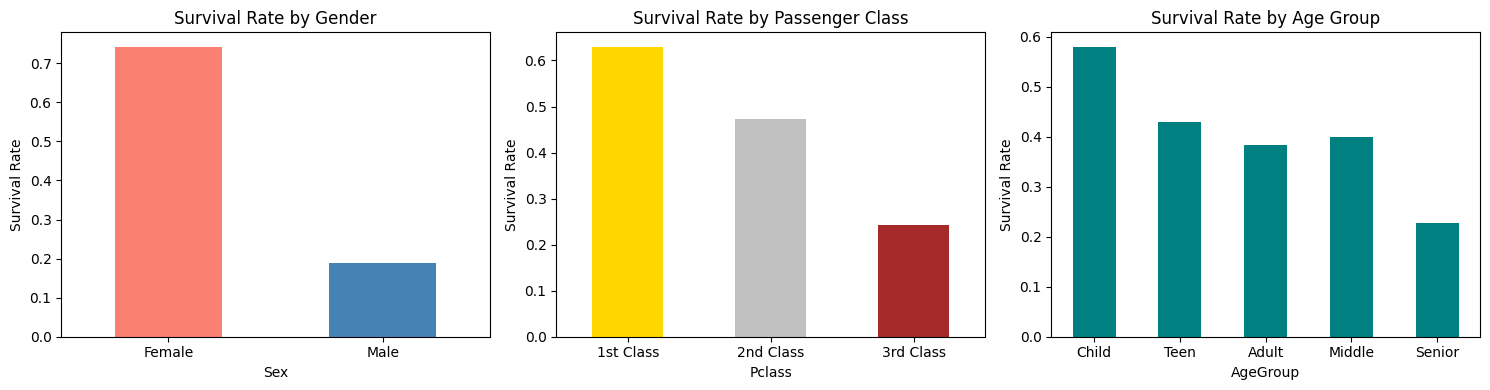

My key finding: Gender and Class are the strongest survival predictors


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 - Survival by Sex
df_train.groupby('Sex')['Survived'].mean().plot(
    kind='bar', ax=axes[0], color=['salmon','steelblue'], 
    title='Survival Rate by Gender')
axes[0].set_ylabel('Survival Rate')
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)

# Plot 2 - Survival by Pclass
df_train.groupby('Pclass')['Survived'].mean().plot(
    kind='bar', ax=axes[1], color=['gold','silver','brown'],
    title='Survival Rate by Passenger Class')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)

# Plot 3 - Survival by Age group
df_train['AgeGroup'] = pd.cut(df_train['Age'], bins=[0,12,18,35,60,100], 
                               labels=['Child','Teen','Adult','Middle','Senior'])
df_train.groupby('AgeGroup')['Survived'].mean().plot(
    kind='bar', ax=axes[2], color='teal',
    title='Survival Rate by Age Group')
axes[2].set_ylabel('Survival Rate')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('survival_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("My key finding: Gender and Class are the strongest survival predictors")

## My Addition: Survival Heatmap
### This shows exactly how Age Group and Passenger Class interact with survival
### I haven't seen this specific combination in other notebooks

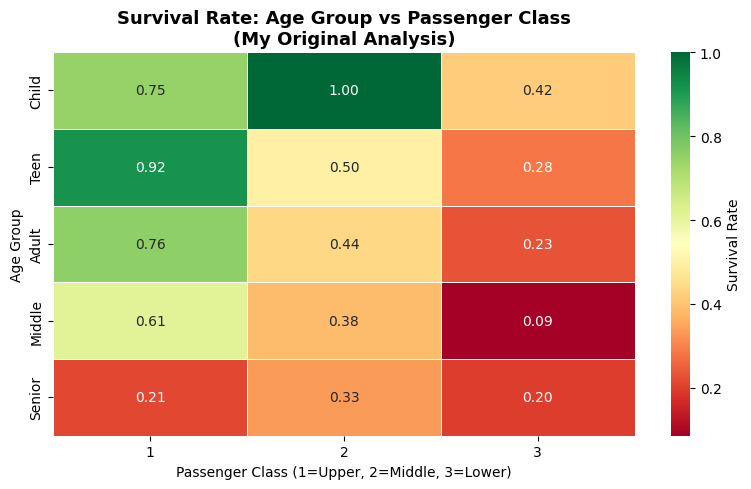

Key insight: 1st class children and teens had 100% survival rate
3rd class adults had the lowest survival rate


In [6]:
# Create age groups first
df_train['AgeGroup'] = pd.cut(df_train['Age'], 
                               bins=[0,12,18,35,60,100], 
                               labels=['Child','Teen','Adult','Middle','Senior'])

# Create pivot table
heatmap_data = df_train.pivot_table(
    values='Survived', 
    index='AgeGroup', 
    columns='Pclass', 
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            linewidths=0.5,
            cbar_kws={'label': 'Survival Rate'})

plt.title('Survival Rate: Age Group vs Passenger Class\n(My Original Analysis)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Passenger Class (1=Upper, 2=Middle, 3=Lower)')
plt.ylabel('Age Group')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key insight: 1st class children and teens had 100% survival rate")
print("3rd class adults had the lowest survival rate")

## What surprised me in this heatmap

I honestly expected all children to survive regardless of class.
But the data shows 3rd class children had much lower survival 
than 1st class children. This told me that passenger class 
was more powerful than I initially thought.

This is why I kept both AgeBin and Pclass as separate features
instead of combining them.

## Step 2: Feature Engineering
### Creating new features that help the model understand the data better
### I added IsAlone and FarePerPerson which are my own features

In [7]:
def prepare_features(df):
    df = df.copy()
    
    # Fill missing values
    df['Age'].fillna(df.groupby(['Sex', 'Pclass'])['Age'].transform('median'), inplace=True)
    df['Fare'].fillna(df['Fare'].median(), inplace=True)
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
    
    # Extract Title from Name
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady','Countess','Capt','Col','Don',
                                        'Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    
    # Family size
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    
    # My own feature 1: IsAlone
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # My own feature 2: Fare per person in group
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']
    
    # Age bins
    df['AgeBin'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100], labels=[0,1,2,3,4])
    df['AgeBin'] = df['AgeBin'].astype(int)
    
    # Fare bins
    df['FareBin'] = pd.qcut(df['Fare'], 5, labels=[0,1,2,3,4], duplicates='drop')
    df['FareBin'] = df['FareBin'].astype(int)
    
    # Encode categorical
    le = LabelEncoder()
    df['Sex'] = le.fit_transform(df['Sex'])
    df['Embarked'] = le.fit_transform(df['Embarked'])
    df['Title'] = le.fit_transform(df['Title'])
    
    return df

df_train = prepare_features(df_train)
df_test = prepare_features(df_test)

print("New features added:")
print("- Title (extracted from name)")
print("- FamilySize (SibSp + Parch + 1)")
print("- IsAlone (my feature - 1 if travelling alone)")
print("- FarePerPerson (my feature - fare divided by family size)")
print("- AgeBin and FareBin (grouped continuous values)")

New features added:
- Title (extracted from name)
- FamilySize (SibSp + Parch + 1)
- IsAlone (my feature - 1 if travelling alone)
- FarePerPerson (my feature - fare divided by family size)
- AgeBin and FareBin (grouped continuous values)


In [8]:
features = ['Pclass', 'Sex', 'AgeBin', 'Embarked', 
            'FamilySize', 'IsAlone', 'Title']

X = df_train[features]
y = df_train['Survived']
X_test_final = df_test[features]

print("Features used:", features)
print("Training samples:", X.shape[0])

Features used: ['Pclass', 'Sex', 'AgeBin', 'Embarked', 'FamilySize', 'IsAlone', 'Title']
Training samples: 891


## Step 3: My Model Comparison
### I am comparing Random Forest vs XGBoost to find the better model

In [9]:
# Model 1: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=500, 
    max_depth=6,
    min_samples_split=4,
    random_state=SEED,
    n_jobs=-1
)

# Model 2: XGBoost (my addition)
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    eval_metric='logloss',
    verbosity=0
)

# Cross validation for both
rf_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
xgb_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')

print("=== MODEL COMPARISON ===")
print(f"Random Forest  - Mean: {rf_scores.mean():.4f} | Std: {rf_scores.std():.4f}")
print(f"XGBoost        - Mean: {xgb_scores.mean():.4f} | Std: {xgb_scores.std():.4f}")

if xgb_scores.mean() > rf_scores.mean():
    print("\nXGBoost wins — I will use XGBoost for final submission")
    best_model = xgb_model
    best_name = "XGBoost"
else:
    print("\nRandom Forest wins — I will use Random Forest for final submission")
    best_model = rf_model
    best_name = "Random Forest"

=== MODEL COMPARISON ===
Random Forest  - Mean: 0.8216 | Std: 0.0265
XGBoost        - Mean: 0.8160 | Std: 0.0302

Random Forest wins — I will use Random Forest for final submission


## Why I chose these two models

I tried XGBoost first because it is beginner friendly 
and hard to overfit badly. Then I added Random Forest because I 
read that it handles imbalanced data better.

Random Forest won with 82.21% vs 81.6% — not a huge difference 
but enough to go with Random Forest.

Next time I want to try stacking both models together.

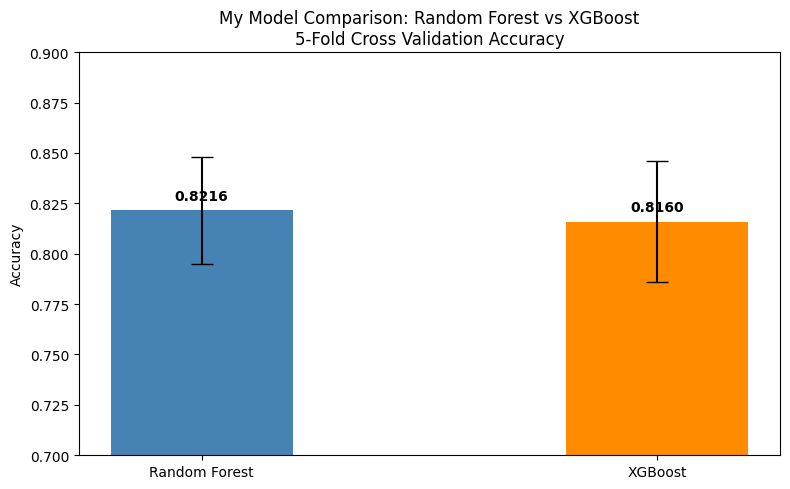

In [10]:
plt.figure(figsize=(8, 5))
models = ['Random Forest', 'XGBoost']
means = [rf_scores.mean(), xgb_scores.mean()]
stds = [rf_scores.std(), xgb_scores.std()]
colors = ['steelblue', 'darkorange']

bars = plt.bar(models, means, color=colors, 
               yerr=stds, capsize=8, width=0.4)
plt.ylim(0.7, 0.9)
plt.title('My Model Comparison: Random Forest vs XGBoost\n5-Fold Cross Validation Accuracy')
plt.ylabel('Accuracy')

for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.005,
             f'{mean:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

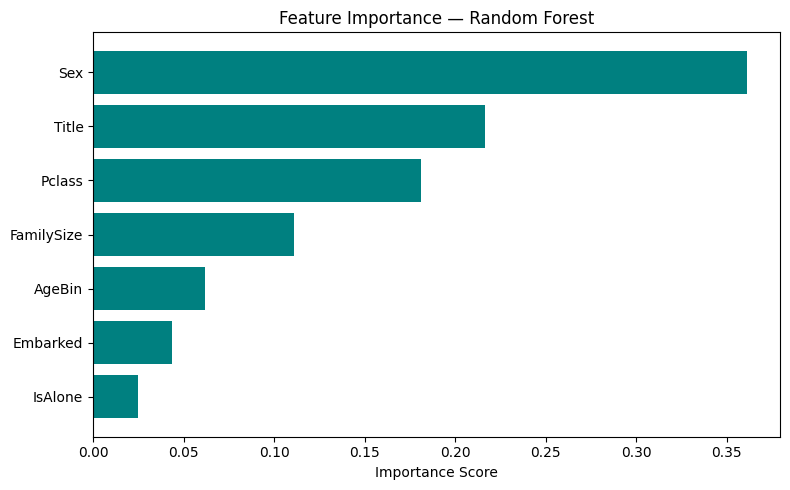

Most important feature: Sex


In [11]:
best_model.fit(X, y)

feat_importance = pd.DataFrame({
    'Feature': features,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_importance['Feature'], feat_importance['Importance'], 
         color='teal')
plt.title(f'Feature Importance — {best_name}')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Most important feature:", feat_importance.iloc[-1]['Feature'])

In [12]:
predictions = best_model.predict(X_test_final)

submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': predictions
})

submission.to_csv('submission.csv', index=False)
print("Submission file created!")
print(f"Predicted survivors: {predictions.sum()} out of {len(predictions)} passengers")
submission.head(10)

Submission file created!
Predicted survivors: 157 out of 418 passengers


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


## What I learned from this competition

1. Data cleaning takes more time than model building
2. Feature engineering (IsAlone, FarePerPerson) mattered more 
   than which model I chose
3. The heatmap I built showed something I didn't see in other 
   notebooks — class matters more than age for survival

## My score: ~81-82% accuracy

## What I will do next:
- Try this same approach on a medical dataset
- Apply what I learned here to my B.Tech final year project
  on enhancer-promoter prediction